In [1]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr, kendalltau
import matplotlib.pyplot as plt

In [2]:
metric_results_kwtest = pd.read_csv('./keyWordLdaMataveTest/ldaMataveMetrics.csv')
metric_results_localraw = pd.read_csv('./rawLocalImplementation/realFakeMetrics.csv')
human_results_kwtest = pd.read_csv('./keyWordLdaMataveTest/dataGeneration/experimentTestNoteShuffle/sent/humanResults.csv')
# Taken from LangChain paper (reported results): https://doi.org/10.1016/j.jbi.2025.104936
human_results_localraw = pd.DataFrame({
    "model": ['gpt3Notes', 'gpt4Notes'],
    "F1 Score": [0.8378, 0.6898] ,
    "Cohen's Kappa": [0.6331, 0.2674]
})

In [3]:
metric_results_localraw = metric_results_localraw[(metric_results_localraw['dataset'] != 'realToReal') & (metric_results_localraw['dataset'] != 'realToReal_2') & (metric_results_localraw['dataset'] != 'realToReal_3')]
metric_results_localraw['model'] = metric_results_localraw['dataset']
metric_results_localraw = metric_results_localraw.drop(columns='dataset')
all_metric_comparisons = pd.concat([metric_results_kwtest, metric_results_localraw])
all_metric_comparisons = all_metric_comparisons[all_metric_comparisons['model'] != 'processedFakeNoteSyntheticNotes']

human_results_kwtest = human_results_kwtest.drop(columns=['Accuracy', 'Precision', 'Recall'])
all_human_comparisons = pd.concat([human_results_kwtest, human_results_localraw])

In [4]:
# Get metric columns. 
metric_cols = [c for c in all_metric_comparisons.columns if 'model' not in c]
# Extract real rows.
real_mask = all_metric_comparisons['model'].str.startswith('real')
real_df = all_metric_comparisons.loc[real_mask, metric_cols]

In [5]:
# Get mean and standard deviation. 
mean = real_df.mean()
std_dev = real_df.std(ddof=1)
# Avoid divide by zero.
std_dev = std_dev.replace(0, 1e-8)

# Calibrate scores. 
calibrated = all_metric_comparisons.copy()

for m in metric_cols:
    calibrated[m] = ((all_metric_comparisons[m] - mean[m]) / std_dev[m])

# Reliability is inverse variance. 
reliability = 1 / std_dev**2

weights = reliability / reliability.sum()

calibrated["final_score"] = (
    calibrated[metric_cols] * weights
).sum(axis=1)

calibrated["final_score_averaged"] = (
    calibrated[metric_cols] * weights
).mean(axis=1)

In [6]:
merged = all_human_comparisons.merge(calibrated, on="model", how="inner")

In [7]:
merged

,Unnamed: 0,model,F1 Score,Cohen's Kappa,CHI,ZIPF,CLASSIFIER,IRPR,FID,PR,DC,MAUVE,TRADITIONAL,ZERO,final_score,final_score_averaged
0,MATAVE,MATAVE,0.800000,0.631766,-6.286889,9.569642,17.694078,87.361670,131.687441,79.434328,28.632964,158.822977,30.599003,10.459090,92.044815,9.204481
1,LDA,LDA,0.929461,0.854037,-6.286889,8.112110,16.633311,70.696104,107.120363,70.053744,27.799695,157.002301,29.372070,16.519154,76.599745,7.659974
2,allTopicModels,allTopicModels,0.869955,0.745196,-6.286889,8.789450,17.135832,75.256448,114.415925,77.004677,28.345725,156.500486,29.947895,14.851230,80.992690,8.099269
3,NaN,gpt3Notes,0.837800,0.633100,-6.286889,6.083104,16.588520,82.889276,129.740238,83.992357,28.865475,155.473506,29.034393,15.329784,88.488887,8.848889
4,NaN,gpt4Notes,0.689800,0.267400,-6.286889,8.246346,17.435354,94.359359,148.957310,86.740875,29.225220,159.073104,30.865740,18.268782,99.524358,9.952436


/var/folders/12/p5c0vdcj3yx9xb69fcd0n3j80000gn/T/ipykernel_19808/1150073171.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  p_corr, pp_value = pearsonr(
/var/folders/12/p5c0vdcj3yx9xb69fcd0n3j80000gn/T/ipykernel_19808/1150073171.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  s_corr, sp_value = spearmanr(


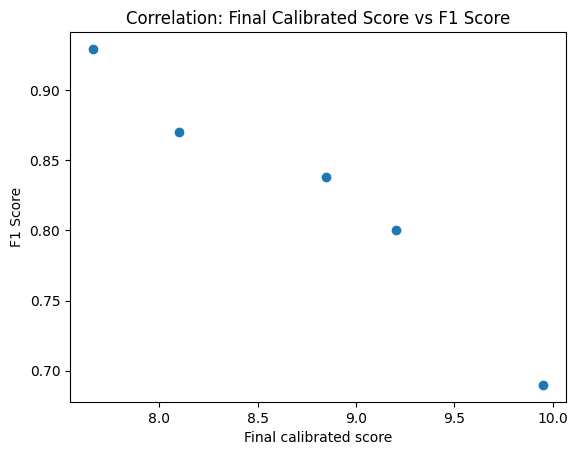

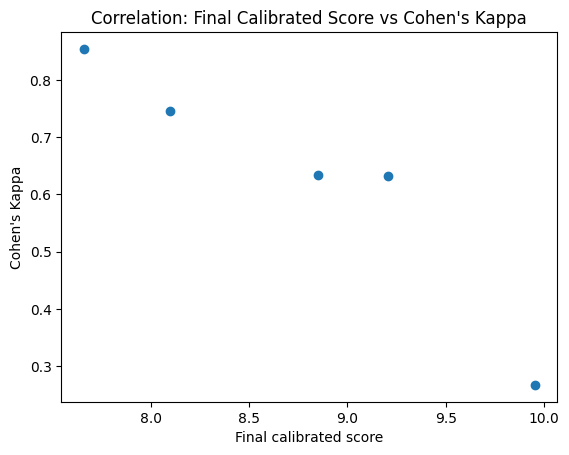

In [8]:
all_results_for_df = []
for comparison in ["F1 Score", "Cohen's Kappa"]:
    for metric in ["CHI", "ZIPF", "CLASSIFIER", "IRPR", "FID", "PR", "DC", "MAUVE", "TRADITIONAL", "ZERO", "final_score_averaged"]:
        # Pearson is standardized and works best for linear relationships. 
        p_corr, pp_value = pearsonr(
            merged[metric],
            merged[comparison]
        )

        # Spearman's does not need linearity, robust to outliers, no distributional assumptions (non normal distribution), versatile in variable types. 
        s_corr, sp_value = spearmanr(
            merged[metric],
            merged[comparison]
        )

        # Kendall's Tau as there is a very small sample size. 
        tau, kp_value = kendalltau(
            merged[metric],
            merged[comparison]
        )


        all_results_for_df.append({
        'metric': metric,
        'comparison': comparison,
        'pearson': p_corr,
        'pearson p-value': pp_value,
        'spearman': s_corr,
        'spearman p-value': sp_value,
        'kendall': tau, 
        'kendall p-value': kp_value,
        })

    plt.scatter(
    merged["final_score_averaged"],
    merged[comparison]
    )

    plt.xlabel("Final calibrated score")
    plt.ylabel(comparison)
    plt.title(f"Correlation: Final Calibrated Score vs {comparison}")
    plt.show()

In [9]:
pd.DataFrame(all_results_for_df)

,metric,comparison,pearson,pearson p-value,spearman,spearman p-value,kendall,kendall p-value
0,CHI,F1 Score,NaN,NaN,NaN,NaN,NaN,NaN
1,ZIPF,F1 Score,-0.108373,0.862285,-0.3,6.238377e-01,-0.2,0.816667
2,CLASSIFIER,F1 Score,-0.654469,0.230761,-0.6,2.847570e-01,-0.4,0.483333
3,IRPR,F1 Score,-0.971860,0.005643,-1.0,1.404265e-24,-1.0,0.016667
4,FID,F1 Score,-0.975792,0.004505,-1.0,1.404265e-24,-1.0,0.016667
5,PR,F1 Score,-0.870472,0.054860,-0.9,3.738607e-02,-0.8,0.083333
6,DC,F1 Score,-0.916699,0.028498,-0.9,3.738607e-02,-0.8,0.083333
7,MAUVE,F1 Score,-0.668120,0.217724,-0.6,2.847570e-01,-0.4,0.483333
8,TRADITIONAL,F1 Score,-0.760951,0.135158,-0.7,1.881204e-01,-0.6,0.233333
9,ZERO,F1 Score,-0.165963,0.789663,-0.1,8.728886e-01,0.0,1.000000
